## Monte Carlo - Forecasting Stock Prices - Part III

*Suggested Answers follow (usually there are multiple ways to solve a problem in Python).*

Forecasting Future Stock Prices – continued:

In [1]:
import numpy as np  
import pandas as pd  
from pandas_datareader import data as wb  
import matplotlib.pyplot as plt  
from scipy.stats import norm
%matplotlib inline

data = pd.read_csv(r'C:\Users\Admin\OneDrive\Documents\bt ptdl\bt_tuan_ptdl\DA08 - Tri tue nhan tao trong tai chinh\01_monte_carlos-20251101T020809Z-1-001\01_monte_carlos\02_Monte Carlo - Predicting Stock Prices\csv\MSFT_2000.csv', index_col = 'Date')

log_returns = np.log(1 + data.pct_change())
u = log_returns.mean()
var = log_returns.var()
drift = u - (0.5 * var)
stdev = log_returns.std()

drift.values
stdev.values

t_intervals = 250
iterations = 10

daily_returns = np.exp(drift.values + stdev.values * norm.ppf(np.random.rand(t_intervals, iterations)))

***

Create a variable S0 equal to the last adjusted closing price of Microsoft. Use the “iloc” method.

In [2]:
S0 = data.iloc[-1]
S0

MSFT    77.610001
Name: 2017-10-18, dtype: float64

Create a variable price_list with the same dimension as the daily_returns matrix. 

In [3]:
price_list = np.zeros_like(daily_returns)
price_list

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Set the values on the first row of the price_list array equal to S0.

In [5]:
price_list[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [6]:
price_list[0] = S0
price_list

array([[77.610001, 77.610001, 77.610001, ..., 77.610001, 77.610001,
        77.610001],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       ...,
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ]])

Create a loop in the range (1, t_intervals) that reassigns to the price in time t the product of the price in day (t-1) with the value of the daily returns in t.

In [7]:
for t in range(1, t_intervals):
    price_list[t] = price_list[t - 1] * daily_returns[t]

In [8]:
price_list

array([[ 77.610001  ,  77.610001  ,  77.610001  , ...,  77.610001  ,
         77.610001  ,  77.610001  ],
       [ 78.76767511,  76.92046085,  78.3073383 , ...,  76.76828106,
         77.40733274,  79.68094613],
       [ 77.99806851,  75.64231841,  78.00219086, ...,  75.33671035,
         77.62466009,  80.70951824],
       ...,
       [ 77.96395764, 178.24310423,  93.54799921, ...,  58.0209246 ,
         49.57410997,  61.23646114],
       [ 77.00719805, 180.290867  ,  92.76483742, ...,  58.56917496,
         48.44589485,  60.26792894],
       [ 77.14764395, 182.8737764 ,  93.65721518, ...,  55.24208939,
         48.2989714 ,  59.32109362]])

Finally, plot the obtained price list data.

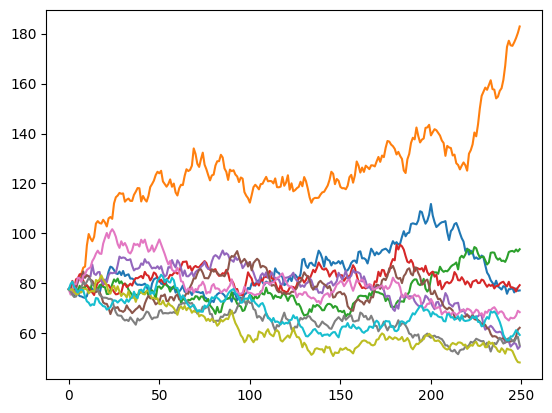

In [11]:
plt.Figure(figsize=(10, 6))
plt.plot(price_list);